In [ ]:
# default (no conditioning, no masking the velocity)

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torchdyn.core import NeuralODE
from torchcfm.conditional_flow_matching import ExactOptimalTransportConditionalFlowMatcher
from matplotlib import animation
import numpy as np
import load_and_preprocess as lap
import train_and_eval_functions as taef
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
label = 'otfm_40mhz_sigma0p01_v2'
save_path = '/global/homes/m/mcohen54/ctfm_development/trained_models/trial_2'

batchSize = 512
numberOfEpochs = 20
patience = 5

pxpypz = True
p_train = 0.5
p_test = 0.25
plots_path = save_path+'/plots'

input_dim = 3
model_dim = 128
ff_dim = 128
num_heads = 4
num_layers = 4
n_mask_vals = 5 # 4 particle types + 1 padding

flowSigma = 0.01

trained = True
multiGPU = True


if not multiGPU:
    os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
datasets = lap.load_and_preprocess(
    p_train=p_train,
    p_test=p_test,
    plots_path=plots_path,
    pxpypz=pxpypz
    )

Extracting...
Loaded bkg
Loaded a4l
Loaded htaunu
Loaded htautau
Loaded lq
a4l: (55969, 19, 4)
htaunu: (760272, 19, 4)
htautau: (691283, 19, 4)
lq: (340544, 19, 4)
bkg_train: (2000000, 19, 4)
bkg_test: (1000000, 19, 4)
bkg_val: (1000000, 19, 4)


In [4]:
class TransformerVectorField(nn.Module):
    def __init__(self, input_dim=3, model_dim=128, num_heads=8, num_layers=4):
        super().__init__()
        self.model_dim = model_dim

        self.input_proj = nn.Linear(input_dim, model_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(1, model_dim),
            nn.SiLU(),
            nn.Linear(model_dim, model_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.output_proj = nn.Linear(model_dim, input_dim)

    def forward(self, t, x, mask=None, **kwargs):
        # x: [B, N, D], mask: [B, N, 1]
        B, N, D = x.shape
        x_proj = self.input_proj(x)

        # Time embedding
        if isinstance(t, float) or len(t.shape) == 0:
            t = torch.full((B, 1), t, device=x.device)
        elif len(t.shape) == 1:
            t = t.view(-1, 1)
        time_emb = self.time_mlp(t)[:, None, :]  # [B, 1, model_dim]

        x_time = x_proj + time_emb

        # Transformer expects padding mask where True = "ignore"
        src_key_padding_mask = None
        if mask is not None:
            src_key_padding_mask = (mask == 0)[:, :, 0]  # [B, N], mask == 0 means padding

        out = self.transformer(x_time, src_key_padding_mask=src_key_padding_mask)
        return self.output_proj(out)

In [5]:
def train(model, dataloader, optimizer, device, num_epochs=50, sigma=0.0):
    model.to(device)
    FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

    for epoch in range(num_epochs):
        total_loss = 0.
        
        for i, data in enumerate(tqdm(dataloader)):
            optimizer.zero_grad()
            x1, mask = data
            x1 = x1.to(device)
            mask = mask.to(device)
            x0 = torch.randn_like(x1)
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
            vt = model(t, xt, mask)
            loss = torch.mean((vt - ut) ** 2)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")

In [6]:
class EvtDataset(Dataset):
    def __init__(self, evts):  # jets: [N, maxparts, 4]
        self.x = evts[:, :, :3]           # [eta, phi, pt]
        self.mask = evts[:, :, 3:]        # [mask]

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.mask[idx]

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = EvtDataset(datasets['bkg_train']['data'].astype(np.float32))
dataloader = DataLoader(dataset, batch_size=batchSize, shuffle=True, drop_last=True)

model = TransformerVectorField(input_dim=input_dim, model_dim=model_dim, num_heads=num_heads, num_layers=num_layers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

if not trained:
    train(model, dataloader, optimizer, device=device, num_epochs=numberOfEpochs, sigma=flowSigma)
    
    # Assuming `node` is your trained NeuralODE (e.g., torchcfm.NeuralODE)
    torch.save({
        'state_dict': model.state_dict(),
        'model_kwargs': {
            'input_dim': input_dim,
            'model_dim': model_dim,
            'num_heads': num_heads,
            'num_layers': num_layers
        }
    }, f"{save_path}/{label}.pt")

else:
    # Rebuild the vector field
    ckpt = torch.load(f"{save_path}/{label}.pt", map_location=device)
    
    # Recreate the architecture
    model = TransformerVectorField(**ckpt['model_kwargs'])
    model.load_state_dict(ckpt['state_dict'])
    model.to(device).eval()

node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [ ]:
# animate flows

In [8]:
def map_to_base_distribution(node, x1, mask, batch_size=1024):
    """
    Maps x1 (data space) to x0 (base space) using the inverse flow in batches.
    Applies mask to ignore padded particles.
    
    Args:
        node: A trained NeuralODE.
        x1: [B, N, D] torch.Tensor - data space samples.
        mask: [B, N, 1] torch.Tensor - binary mask for valid particles.
        batch_size: int - batch size for processing.

    Returns:
        x0: [B, N, D] torch.Tensor - mapped base samples with mask applied.
    """
    t_span = torch.linspace(1., 0., 2, device=x1.device)
    outputs = []

    for i in tqdm(range(0, x1.size(0), batch_size)):
        xb = x1[i:i+batch_size]
        mb = mask[i:i+batch_size]

        with torch.no_grad():
            traj = node.trajectory(xb, t_span=t_span)  # [2, bsz, N, D]
            x0_b = traj[-1] * mb  # Apply mask

        outputs.append(x0_b)

    return torch.cat(outputs, dim=0)

In [9]:
skip_tags = ['bkg_val', 'bkg_train']
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    
    torch_data = torch.tensor(data_dict['data'], dtype=torch.float32).to(device)
    torch_x = torch_data[:,:,:3]
    torch_mask = torch_data[:,:,3:]

    data_dict['x0_latent'] = map_to_base_distribution(node, torch_x, torch_mask)
    data_dict['torch_mask'] = torch_mask

    print(tag)
    print("Mapped shape:", data_dict['x0_latent'].shape)  # Should be [B, maxparts, 3]
    print("Latent mean (should be ~0):", data_dict['x0_latent'].mean().item())
    print("Latent std (should be ~1):", data_dict['x0_latent'].std().item())

100%|██████████| 55/55 [00:15<00:00,  3.50it/s]


a4l
Mapped shape: torch.Size([55969, 19, 3])
Latent mean (should be ~0): 0.0673804059624672
Latent std (should be ~1): 4.352743625640869


100%|██████████| 743/743 [03:32<00:00,  3.50it/s]


htaunu
Mapped shape: torch.Size([760272, 19, 3])
Latent mean (should be ~0): -0.04739565774798393
Latent std (should be ~1): 4.631986141204834


100%|██████████| 676/676 [03:07<00:00,  3.61it/s]


htautau
Mapped shape: torch.Size([691283, 19, 3])
Latent mean (should be ~0): 0.02940799482166767
Latent std (should be ~1): 3.938589334487915


100%|██████████| 333/333 [01:32<00:00,  3.62it/s]


lq
Mapped shape: torch.Size([340544, 19, 3])
Latent mean (should be ~0): 0.030846575275063515
Latent std (should be ~1): 4.406839847564697


100%|██████████| 977/977 [03:48<00:00,  4.28it/s]

bkg_test
Mapped shape: torch.Size([1000000, 19, 3])
Latent mean (should be ~0): -0.0006261263624764979
Latent std (should be ~1): 2.171203136444092


In [12]:
from scipy.stats import norm, stats

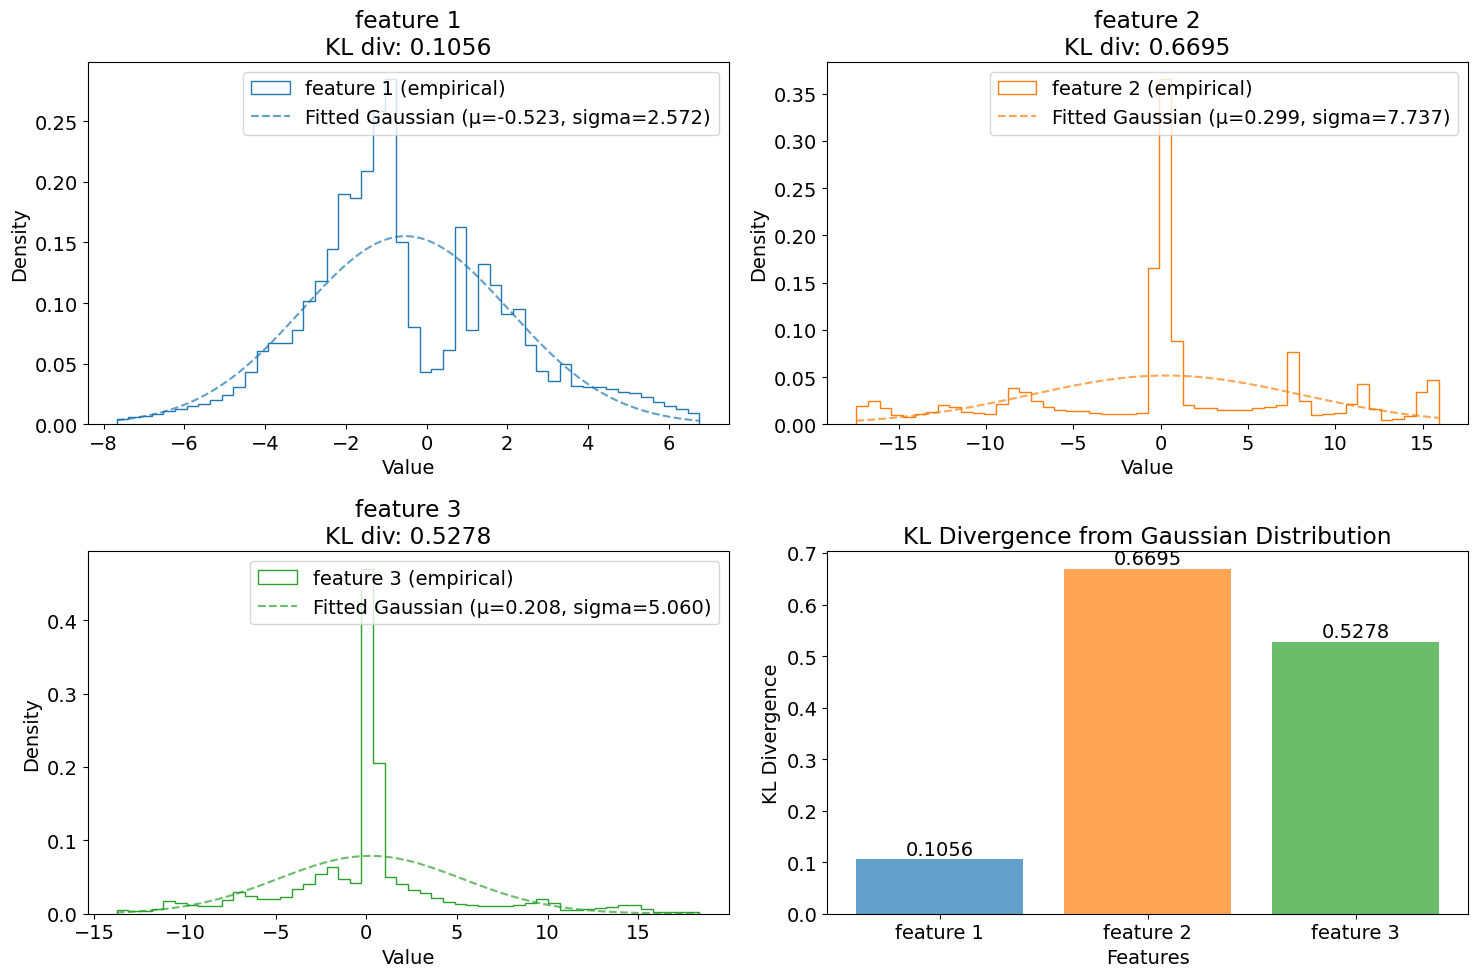

=== Gaussian Deviation Analysis ===
KL Divergence (lower = more Gaussian-like):
  feature 1: KL = 0.105636
    Fitted params: μ = -0.5233, sigma = 2.5719
  feature 2: KL = 0.669500
    Fitted params: μ = 0.2995, sigma = 7.7368
  feature 3: KL = 0.527808
    Fitted params: μ = 0.2075, sigma = 5.0604

Most Gaussian-like feature: feature 1
Least Gaussian-like feature: feature 2


In [23]:
# plot features post flow
def get_valid_feature(data_dict, feature_idx):
    # [B, N, D] for x0_latent, [B, N, 1] for mask
    x0 = data_dict['x0_latent'][:,:,feature_idx].flatten()
    mask = data_dict['torch_mask'].flatten() > 0.5
    # Ensure both are on CPU and numpy
    x0 = x0[mask].cpu().numpy()
    return x0

def calculate_kl_divergence_to_gaussian(data, bins=100):
    """
    Calculate KL divergence between empirical distribution and fitted Gaussian
    """
    # Fit Gaussian to the data
    mu, sigma = norm.fit(data)
    
    # Create histogram
    hist, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Calculate empirical probabilities (normalize histogram)
    empirical_probs = hist * bin_width
    
    # Calculate theoretical Gaussian probabilities
    gaussian_probs = norm.pdf(bin_centers, mu, sigma) * bin_width
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    empirical_probs = np.maximum(empirical_probs, epsilon)
    gaussian_probs = np.maximum(gaussian_probs, epsilon)
    
    # Calculate KL divergence: D_KL(P||Q) = sum(P * log(P/Q))
    # where P is empirical and Q is Gaussian
    kl_div = np.sum(empirical_probs * np.log(empirical_probs / gaussian_probs))
    
    return kl_div, mu, sigma


plt.figure(figsize=(15, 10))
feature_names = ['feature 1', 'feature 2', 'feature 3']
colors = ['C0', 'C1', 'C2']

# Store results
kl_divergences = []
gaussian_params = []

for i in range(3):
    # filter by percentiles
    data = get_valid_feature(datasets['bkg_test'], i)
    lower, upper = np.percentile(data, [1, 99])
    data = data[(data >= lower) & (data <= upper)]
    
    # Calculate KL divergence and fitted parameters
    kl_div, mu, sigma = calculate_kl_divergence_to_gaussian(data)
    kl_divergences.append(kl_div)
    gaussian_params.append((mu, sigma))

    # Plot histogram
    plt.subplot(2, 2, i+1)
    plt.hist(data, bins=50, histtype='step', density=True, label=f'{feature_names[i]} (empirical)', color=colors[i])
    
    # Overlay fitted Gaussian
    x = np.linspace(data.min(), data.max(), 200)
    plt.plot(x, norm.pdf(x, mu, sigma), color=colors[i], linestyle='dashed', alpha=0.7, 
             label=f'Fitted Gaussian (μ={mu:.3f}, sigma={sigma:.3f})')
    
    plt.legend()
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title(f'{feature_names[i]}\nKL div: {kl_div:.4f}')

# Summary plot
plt.subplot(2, 2, 4)
x_pos = np.arange(len(feature_names))
plt.bar(x_pos, kl_divergences, color=colors, alpha=0.7)
plt.xlabel('Features')
plt.ylabel('KL Divergence')
plt.title('KL Divergence from Gaussian Distribution')
plt.xticks(x_pos, feature_names)

# Add text annotations
for i, kl_div in enumerate(kl_divergences):
    plt.text(i, kl_div + 0.001, f'{kl_div:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'{plots_path}/gaussian_deviation_analysis.png', bbox_inches='tight')
plt.show()

# Print summary results
print("=== Gaussian Deviation Analysis ===")
print("KL Divergence (lower = more Gaussian-like):")
for i, (name, kl_div) in enumerate(zip(feature_names, kl_divergences)):
    mu, sigma = gaussian_params[i]
    print(f"  {name}: KL = {kl_div:.6f}")
    print(f"    Fitted params: μ = {mu:.4f}, sigma = {sigma:.4f}")

print(f"\nMost Gaussian-like feature: {feature_names[np.argmin(kl_divergences)]}")
print(f"Least Gaussian-like feature: {feature_names[np.argmax(kl_divergences)]}")

In [10]:
def neg_log_prob_gaussian(x0, mask):
    """
    Compute -log p(x0) under a standard N-dimensional Gaussian,
    masking out invalid (padded) particles.

    Args:
        x0: [B, N, D] tensor
        mask: [B, N, 1] binary mask tensor (1 = valid, 0 = padded)

    Returns:
        nll: [B] tensor, negative log-likelihood per jet
    """
    # Standard Gaussian: log p(x) = -0.5 * (x^2 + log(2π))
    log_probs = -0.5 * (x0 ** 2 + torch.log(torch.tensor(2 * torch.pi, device=x0.device)))

    # Apply mask and sum over particles and features
    log_probs_masked = log_probs * mask  # [B, N, D]
    log_likelihood = log_probs_masked.sum(dim=(1, 2))  # [B]

    # Return negative log-likelihood
    return -log_likelihood  # [B]

In [11]:
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    data_dict['AD_scores'] = neg_log_prob_gaussian(data_dict['x0_latent'], data_dict['torch_mask']).cpu().numpy()  # [B]
    print(tag)
    print("Mean AD score per event:", np.mean(data_dict['AD_scores']))

a4l
Mean AD score per event: 2022.891
htaunu
Mean AD score per event: 2381.708
htautau
Mean AD score per event: 1711.1857
lq
Mean AD score per event: 2156.354
bkg_test
Mean AD score per event: 470.98022


In [12]:
# Plot AD scores
plt.figure(figsize=(12, 8))
for tag, data_dict in datasets.items():
    if tag in skip_tags:
        continue
    plt.hist(data_dict['AD_scores'], bins=50, histtype='step', density=True, label=tag)

plt.yscale('log')
plt.legend()
plt.savefig(f'{plots_path}/AD_scores_histograms.png')
plt.close()

In [13]:
# ROC curve
plt.figure(figsize=(10, 8))
    
bkg_scores = datasets['bkg_test']['AD_scores']

for tag, data_dict in datasets.items():
    if 'bkg' in tag:
        continue

    sig_scores = data_dict['AD_scores']
    combined_scores = np.concatenate([bkg_scores, sig_scores], axis=0)
    combined_labels = np.concatenate([np.zeros_like(bkg_scores), np.ones_like(sig_scores)], axis=0)

    fpr, tpr, thresholds = roc_curve(combined_labels, combined_scores)
    auroc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{tag} (auc = {auroc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig(f'{plots_path}/roc_curves.png')
plt.close()

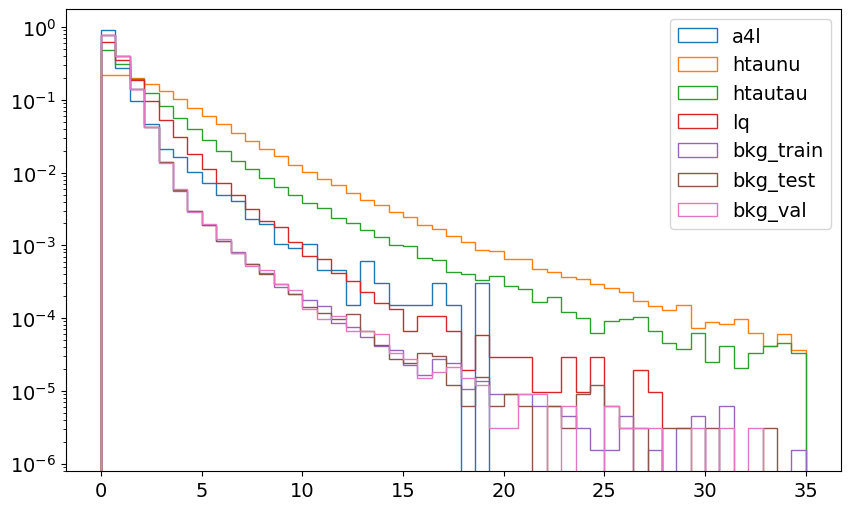

In [14]:
plt.figure(figsize=(10, 6))

for tag, data_dict in datasets.items():
    plt.hist(data_dict['data'][:,0,0], bins=np.linspace(0, 35), histtype='step', density=True, label=tag)

plt.legend()

plt.yscale('log')
plt.show()